<a href="https://colab.research.google.com/github/ruthvik889/Model-Performance-Forecasting-Volatility-Between-INR-USD/blob/main/INR_USD_Volatility_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
data = "https://raw.githubusercontent.com/ruthvik889/Model-Performance-Forecasting-Volatility-Between-INR-USD/refs/heads/main/exchange_rates.csv"

df = pd.read_csv(data)

df.head()

,Series Description,SPOT EXCHANGE RATE - EURO AREA,"UNITED KINGDOM -- SPOT EXCHANGE RATE, US$/POUND (1/RXI_N.B.UK)",SPOT EXCHANGE RATE - BRAZIL,"CHINA -- SPOT EXCHANGE RATE, YUAN/US$ P.R.","DENMARK -- SPOT EXCHANGE RATE, KRONER/US$","INDIA -- SPOT EXCHANGE RATE, RUPEES/US$","JAPAN -- SPOT EXCHANGE RATE, YEN/US$","KOREA -- SPOT EXCHANGE RATE, WON/US$","MALAYSIA -- SPOT EXCHANGE RATE, RINGGIT/US$",...,"THAILAND -- SPOT EXCHANGE RATE, BAHT/US$",SPOT EXCHANGE RATE - VENEZUELA,Nominal Broad Dollar Index,Nominal Major Currencies Dollar Index,Nominal Other Important Trading Partners Dollar Index,AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL),"NEW ZEALAND -- SPOT EXCHANGE RATE, US$/NZ$ RECIPROCAL OF RXI_N.B.NZ","CANADA -- SPOT EXCHANGE RATE, CANADIAN $/US$","HONG KONG -- SPOT EXCHANGE RATE, HK$/US$","SRI LANKA -- SPOT EXCHANGE RATE, RUPEES/US$"
0,Unit:,Currency:_Per_EUR,Currency:_Per_GBP,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,...,Currency:_Per_USD,Currency:_Per_USD,Index:_1973_Mar_100,Index:_1973_Mar_100,Index:_1997_Jan_100,Currency:_Per_AUD,Currency:_Per_NZD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD
1,Multiplier:,1,0.00999999978,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,Currency:,USD,USD,BRL,CNY,DKK,INR,JPY,KRW,MYR,...,THB,VEB,NaN,NaN,NaN,USD,USD,CAD,HKD,LKR
3,Unique Identifier:,H10/H10/RXI$US_N.B.EU,H10/H10/RXI$US_N.B.UK,H10/H10/RXI_N.B.BZ,H10/H10/RXI_N.B.CH,H10/H10/RXI_N.B.DN,H10/H10/RXI_N.B.IN,H10/H10/RXI_N.B.JA,H10/H10/RXI_N.B.KO,H10/H10/RXI_N.B.MA,...,H10/H10/RXI_N.B.TH,H10/H10/RXI_N.B.VE,H10/H10/JRXWTFB_N.B,H10/H10/JRXWTFN_N.B,H10/H10/JRXWTFO_N.B,H10/H10/RXI$US_N.B.AL,H10/H10/RXI$US_N.B.NZ,H10/H10/RXI_N.B.CA,H10/H10/RXI_N.B.HK,H10/H10/RXI_N.B.SL
4,Time Period,RXI$US_N.B.EU,RXI$US_N.B.UK,RXI_N.B.BZ,RXI_N.B.CH,RXI_N.B.DN,RXI_N.B.IN,RXI_N.B.JA,RXI_N.B.KO,RXI_N.B.MA,...,RXI_N.B.TH,RXI_N.B.VE,JRXWTFB_N.B,JRXWTFN_N.B,JRXWTFO_N.B,RXI$US_N.B.AL,RXI$US_N.B.NZ,RXI_N.B.CA,RXI_N.B.HK,RXI_N.B.SL


In [3]:
# Global Variables
currency_pairs = ["inr_usd", "chi_usd", "uk_usd", "euro_usd", "can_usd"]
cols = ['Series Description', 'INDIA -- SPOT EXCHANGE RATE, RUPEES/US$ ',
        'CHINA -- SPOT EXCHANGE RATE, YUAN/US$ P.R. ',
        'UNITED KINGDOM -- SPOT EXCHANGE RATE, US$/POUND (1/RXI_N.B.UK)',
        'SPOT EXCHANGE RATE - EURO AREA ',
        'CANADA -- SPOT EXCHANGE RATE, CANADIAN $/US$ ']
col_rename_map = {
    "Series Description": "date",
    'INDIA -- SPOT EXCHANGE RATE, RUPEES/US$ ': "inr_usd_rate",
    'CHINA -- SPOT EXCHANGE RATE, YUAN/US$ P.R. ': "chi_usd_rate",
    'UNITED KINGDOM -- SPOT EXCHANGE RATE, US$/POUND (1/RXI_N.B.UK)': "uk_usd_rate",
    'SPOT EXCHANGE RATE - EURO AREA ': "euro_usd_rate",
    'CANADA -- SPOT EXCHANGE RATE, CANADIAN $/US$ ': "can_usd_rate"
}

In [4]:
# Get relevant currencies and clean data
df = df[cols]
df = df[df[cols].notna().all(axis=1)]
df = df[df['Series Description'].str.fullmatch(r"\d{4}-\d{2}-\d{2}", na=False)]
df = df.rename(columns=col_rename_map)

numeric_cols = [f"{pair}_rate" for pair in currency_pairs]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=numeric_cols)
df

,date,inr_usd_rate,chi_usd_rate,uk_usd_rate,euro_usd_rate,can_usd_rate
7310,1999-01-04,42.60,8.2793,1.6581,1.1812,1.5268
7311,1999-01-05,42.56,8.2795,1.6566,1.1760,1.5213
7312,1999-01-06,42.55,8.2795,1.6547,1.1636,1.5110
7313,1999-01-07,42.55,8.2798,1.6495,1.1672,1.5117
7314,1999-01-08,42.55,8.2796,1.6405,1.1554,1.5145
...,...,...,...,...,...,...
12170,2017-08-21,64.10,6.6630,1.2903,1.1814,1.2587
12171,2017-08-22,64.07,6.6600,1.2834,1.1762,1.2559
12172,2017-08-23,64.04,6.6569,1.2787,1.1802,1.2558
12173,2017-08-24,64.04,6.6600,1.2802,1.1801,1.2528


In [5]:
df["date"] = pd.to_datetime(df["date"])

df = df[
    (df["date"] >= "2010-01-01") &
    (df["date"] <= "2016-12-31")
].sort_values("date").reset_index(drop=True)

In [6]:
# Add features

# returns
for pair in currency_pairs:
    df[f"{pair}_return"] = np.log(df[f"{pair}_rate"]).diff()

# one-day-back volatility proxy
for pair in currency_pairs:
    df[f"{pair}_day_back"] = np.abs(df[f"{pair}_return"])

# five-days-back
for pair in currency_pairs:
    df[f"{pair}_five_back"] = np.sqrt(
        (df[f"{pair}_return"] ** 2).rolling(5).sum()
    )

# five-days-ahead
for pair in currency_pairs:
    df[f"{pair}_five_ahead"] = df[f"{pair}_five_back"].shift(-5)

# date corresponding to the future target
df["target_date"] = df["date"].shift(-5)

# one-month-back
for pair in currency_pairs:
    df[f"{pair}_month_back"] = np.sqrt(
        (df[f"{pair}_return"] ** 2).rolling(22).sum()
    )

df = df.dropna()
df

,date,inr_usd_rate,chi_usd_rate,uk_usd_rate,euro_usd_rate,can_usd_rate,inr_usd_return,chi_usd_return,uk_usd_return,euro_usd_return,...,chi_usd_five_ahead,uk_usd_five_ahead,euro_usd_five_ahead,can_usd_five_ahead,target_date,inr_usd_month_back,chi_usd_month_back,uk_usd_month_back,euro_usd_month_back,can_usd_month_back
22,2010-02-05,46.72,6.8275,1.5619,1.3608,1.0727,0.010976,-0.000073,-0.009177,-0.011035,...,0.000744,0.006939,0.012589,0.014252,2010-02-12,0.021986,0.000836,0.030171,0.029790,0.026586
23,2010-02-08,46.79,6.8265,1.5650,1.3699,1.0692,0.001497,-0.000146,0.001983,0.006665,...,0.000729,0.007766,0.013681,0.016947,2010-02-16,0.021828,0.000820,0.029588,0.030504,0.026780
24,2010-02-09,46.49,6.8267,1.5679,1.3795,1.0690,-0.006432,0.000029,0.001851,0.006983,...,0.000729,0.007750,0.014630,0.017157,2010-02-17,0.020931,0.000794,0.029642,0.031293,0.026527
25,2010-02-10,46.36,6.8280,1.5606,1.3722,1.0667,-0.002800,0.000190,-0.004667,-0.005306,...,0.000706,0.009955,0.014331,0.017028,2010-02-18,0.021090,0.000808,0.029292,0.031115,0.026558
26,2010-02-11,46.39,6.8328,1.5674,1.3640,1.0522,0.000647,0.000703,0.004348,-0.005994,...,0.000589,0.012946,0.013147,0.010557,2010-02-19,0.020767,0.001068,0.029174,0.031544,0.029871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1744,2016-12-16,67.82,6.9580,1.2478,1.0456,1.3339,-0.001326,0.002446,0.007158,0.007777,...,0.002123,0.008823,0.006802,0.008438,2016-12-23,0.015026,0.010201,0.035982,0.035539,0.027061
1745,2016-12-19,67.83,6.9506,1.2419,1.0444,1.3395,0.000147,-0.001064,-0.004740,-0.001148,...,0.002024,0.007478,0.006760,0.007472,2016-12-27,0.014492,0.009771,0.036223,0.035468,0.027098
1746,2016-12-20,67.97,6.9470,1.2358,1.0390,1.3376,0.002062,-0.000518,-0.004924,-0.005184,...,0.002187,0.006467,0.007915,0.007337,2016-12-28,0.014492,0.009685,0.036556,0.035618,0.027115
1747,2016-12-21,67.82,6.9390,1.2348,1.0425,1.3401,-0.002209,-0.001152,-0.000810,0.003363,...,0.001891,0.006532,0.011735,0.008655,2016-12-29,0.014391,0.009314,0.035191,0.035386,0.026364


In [7]:
volatility_stats = df[
    ["inr_usd_day_back",
     "inr_usd_five_back",
     "inr_usd_month_back",
     "inr_usd_five_ahead"]
].describe()

volatility_stats

,inr_usd_day_back,inr_usd_five_back,inr_usd_month_back,inr_usd_five_ahead
count,1727.000000,1727.000000,1727.000000,1727.000000
mean,0.003749,0.010256,0.022943,0.010229
std,0.003903,0.006431,0.010913,0.006436
min,0.000000,0.001249,0.006699,0.001249
25%,0.001133,0.006137,0.016113,0.006068
50%,0.002663,0.009009,0.020310,0.008933
75%,0.005085,0.012255,0.026597,0.012183
max,0.037919,0.067266,0.085991,0.067266


**MODELS**


*   HAR-RV Style Linear Regression
*   Random Forest Regression



In [8]:
# ---------------------------
# MODEL COMPARISON
# ---------------------------

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Predictors and target
X = df[
    [
        "inr_usd_day_back",
        "inr_usd_five_back",
        "inr_usd_month_back"
    ]
]

y = df["inr_usd_five_ahead"]

# Test on 2016 data, train on 2010-2015
train_mask = df["target_date"] < "2016-01-01"
test_mask = df["date"] >= "2016-01-01"

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]


# LINEAR REGRESSION

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

# # in-sample
# linear_predictions = linear_model.predict(
#     X_train
# )


# RANDOM FOREST

random_forest = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)


# METRICS FUNCTION

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape
    }


linear_metrics = calculate_metrics(
    y_test,
    linear_predictions
)

rf_metrics = calculate_metrics(
    y_test,
    rf_predictions
)


results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **linear_metrics
    },
    {
        "Model": "Random Forest",
        **rf_metrics
    }
])

display(results)


# INDIVIDUAL PREDICTIONS

prediction_results = pd.DataFrame({
    "date": df.loc[test_mask, "date"].values,
    "actual_volatility": y_test.values,
    "linear_prediction": linear_predictions,
    "random_forest_prediction": rf_predictions,
})

display(prediction_results)

,Model,MAE,MSE,RMSE,MAPE
0,Linear Regression,0.002821,0.000011,0.003361,65.505849
1,Random Forest,0.003094,0.000014,0.003733,76.463630


,date,actual_volatility,linear_prediction,random_forest_prediction
0,2016-01-04,0.003779,0.008490,0.009169
1,2016-01-05,0.003778,0.008050,0.009572
2,2016-01-06,0.002465,0.008251,0.008890
3,2016-01-07,0.009709,0.007842,0.008164
4,2016-01-08,0.011065,0.007747,0.007167
...,...,...,...,...
241,2016-12-16,0.003097,0.008290,0.007283
242,2016-12-19,0.003979,0.008032,0.008501
243,2016-12-20,0.004400,0.008250,0.008279
244,2016-12-21,0.005713,0.008313,0.008371


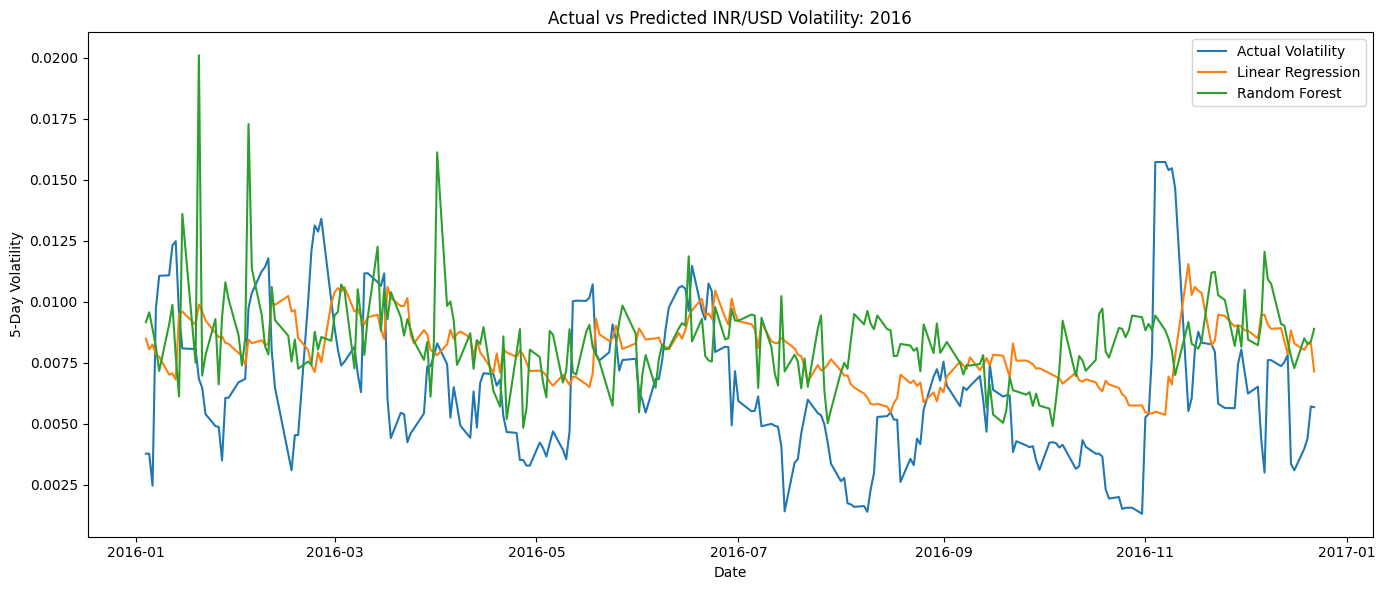

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    prediction_results["date"],
    prediction_results["actual_volatility"],
    label="Actual Volatility"
)

plt.plot(
    prediction_results["date"],
    prediction_results["linear_prediction"],
    label="Linear Regression"
)

plt.plot(
    prediction_results["date"],
    prediction_results["random_forest_prediction"],
    label="Random Forest"
)

plt.xlabel("Date")
plt.ylabel("5-Day Volatility")
plt.title("Actual vs Predicted INR/USD Volatility: 2016")
plt.legend()
plt.tight_layout()
plt.show()